# Binary Logistic Regression #


#### Imports ####

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import os
import pandas as pd
import matplotlib as plt
import seaborn as sns
import matplotlib.pyplot as pyplt
from sklearn.inspection import permutation_importance

#### Load Cleaned Dataset ####


In [2]:
script_dir = os.getcwd()
rel_path = "intermediate"

dataset = pd.read_csv(os.path.join(script_dir, rel_path, "CLEAN_data_injection_moulding.csv"))

#### Feature Selection ####

Initial feature selection is to be the same as that of kNN.

In [3]:
features = ['ZSx [s]', 'ACPx [cm³]', 'ZDx [s]', 'ZEx [s]', 'GEx [kWh]', 'H16x [°C]', 'H10x [°C]', 'H9x [°C]', 'H11x [°C]', 'H15x [°C]', 'MPx [kW]']

X = dataset[features]
y = dataset['ASZ [Sch]']

#### Splitting and Scaling Data ####


In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#### Train Model ####

In [5]:
blr = LogisticRegression()
blr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


#### Evaluate Model ####

In [6]:
y_pred = blr.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       933
           1       0.92      0.87      0.89        38

    accuracy                           0.99       971
   macro avg       0.96      0.93      0.94       971
weighted avg       0.99      0.99      0.99       971



In [7]:
print(dict(zip(features, blr.coef_[0])))

{'ZSx [s]': np.float64(-0.606453808604671), 'ACPx [cm³]': np.float64(0.2915878554424739), 'ZDx [s]': np.float64(-0.05676165096293283), 'ZEx [s]': np.float64(-0.16724816492000008), 'GEx [kWh]': np.float64(1.2065404641806445), 'H16x [°C]': np.float64(-2.259565693855167), 'H10x [°C]': np.float64(-0.06210681249288508), 'H9x [°C]': np.float64(-0.0763566098549679), 'H11x [°C]': np.float64(-0.12627062145334422), 'H15x [°C]': np.float64(0.9981906974813662), 'MPx [kW]': np.float64(2.871182658530523)}


cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()#### Plot Confusion Matrix ####

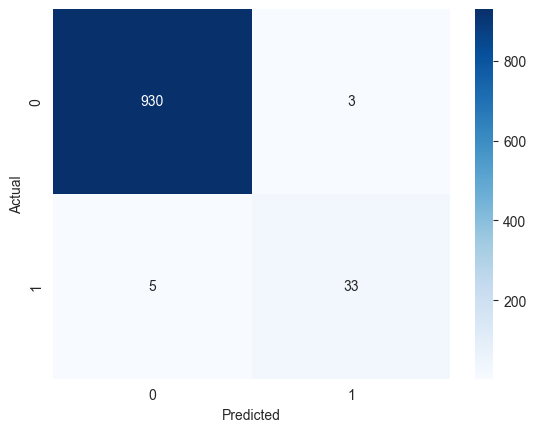

In [8]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
pyplt.xlabel('Predicted')
pyplt.ylabel('Actual')
pyplt.show()

#### Double-checking if one feature is carrying the entire model ####
We shuffle one column at a time and see if the model's performance drops.

In [9]:
results = permutation_importance(blr, X_test, y_test, n_repeats=10, random_state=42)

for i in results.importances_mean.argsort()[::-1]:
    print(f"{features[i]}: {results.importances_mean[i]:.3f}")

H16x [°C]: 0.047
MPx [kW]: 0.021
H15x [°C]: 0.014
ZSx [s]: 0.003
GEx [kWh]: 0.002
ACPx [cm³]: 0.000
ZDx [s]: 0.000
H9x [°C]: -0.000
H10x [°C]: -0.000
ZEx [s]: -0.000
H11x [°C]: -0.001


H16x, MPx and H15x seem to be the main features relevant here. The lower features in the permutation importance list just seem to be either useless or adding noise. Hence they will be removed and the model re-run.

In [10]:
features = ['ZSx [s]', 'GEx [kWh]', 'H16x [°C]', 'H15x [°C]', 'MPx [kW]']

X = dataset[features]
y = dataset['ASZ [Sch]']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test= scaler.transform(X_test)

blr = LogisticRegression()
blr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [11]:
y_pred = blr.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       933
           1       0.92      0.87      0.89        38

    accuracy                           0.99       971
   macro avg       0.96      0.93      0.94       971
weighted avg       0.99      0.99      0.99       971



#### Hyperparameter Optimisation ####

In [12]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# Define the 'Grid' of settings to test
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'], # liblinear works best for small datasets and L1
    'class_weight': ['balanced', {0: 1, 1: 2}, {0: 1, 1: 5}]
}

grid_search = GridSearchCV(
    LogisticRegression(),
    param_grid,
    scoring='f1', # We optimize for F1 to balance Precision and Recall
    cv=5
)

grid_search.fit(X_train, y_train)

print(f"Best Settings: {grid_search.best_params_}")

Best Settings: {'C': 10, 'class_weight': {0: 1, 1: 2}, 'penalty': 'l1', 'solver': 'liblinear'}


In [13]:
import pandas as pd

# Get the coefficients from the best model
best_model = grid_search.best_estimator_
coef_df = pd.DataFrame({'Feature': features, 'Coef': best_model.coef_[0]})

# Filter for non-zero features
active_features = coef_df[coef_df['Coef'] != 0]
print("Features the model actually uses:")
print(active_features)

Features the model actually uses:
     Feature      Coef
0    ZSx [s] -0.573329
1  GEx [kWh]  1.225199
2  H16x [°C] -2.374721
3  H15x [°C]  0.966502
4   MPx [kW]  5.983806


We see that a large spike in MPx is correlated to a defect, a sharp decrease in H16x means the same thing. Now we rerun a new model with the best settings found above.

In [14]:
model = LogisticRegression(
    C=10,
    penalty='l1',
    solver='liblinear',
    class_weight={0: 1, 1: 2},
    random_state=42
)

# 5. Fit the model
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Optimized Confusion Matrix")
print(confusion_matrix(y_test, y_pred))
print("Optimized Classification Report")
print(classification_report(y_test, y_pred))
blr_cr = classification_report(y_test, y_pred, output_dict=True)
%store blr_cr

Optimized Confusion Matrix
[[927   6]
 [  5  33]]
Optimized Classification Report
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       933
           1       0.85      0.87      0.86        38

    accuracy                           0.99       971
   macro avg       0.92      0.93      0.93       971
weighted avg       0.99      0.99      0.99       971

Stored 'blr_cr' (dict)
